# Correlation Analysis of Volatility Compression Features

In this section we analyze the statistical dependency between the engineered
features used for market range detection.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
import networkx as nx

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", None)

In [2]:
path = "C:/Users/LENOVO/AlgoTrading_Research/statistical-range-detection/data/processed/eurusd_h1_features_v4.csv"
df = pd.read_csv(path, parse_dates = ["date"], index_col = "date")

df.head()

,open,high,low,close,tick_volume,spread,returns,log_returns,tr,atr_14,atr_mean_16,atr_mean_48,atr_rel_16,atr_rel_48,std_16,std_48,std_rel_16,std_rel_48,candle_range,range_mean_16,range_mean_48,range_rel_16,range_rel_48,sma20,std20,upper,lower,bb_width,bb_mean_16,bb_mean_48,bb_rel_16,bb_rel_48
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-11-09 05:00:00,1.00813,1.00882,1.00701,1.00718,3261,0,-0.000962,-0.000963,0.00181,0.002146,0.002060,0.001962,1.041956,1.094070,0.003022,0.004129,0.992843,0.585426,0.00181,0.002061,0.001860,0.878374,0.972900,1.004721,0.003812,1.012346,0.997096,0.015178,0.012107,0.011495,1.253643,1.320374
2022-11-09 06:00:00,1.00718,1.00731,1.00647,1.00691,2369,0,-0.000268,-0.000268,0.00084,0.002104,0.002095,0.001946,1.004454,1.081456,0.002450,0.004032,0.784674,0.578158,0.00084,0.002011,0.001864,0.417781,0.450755,1.005153,0.003521,1.012196,0.998110,0.014013,0.012648,0.011254,1.107892,1.245120
2022-11-09 07:00:00,1.00695,1.00732,1.00636,1.00686,2851,0,-0.000050,-0.000050,0.00096,0.001727,0.002104,0.001931,0.821070,0.894341,0.001720,0.003936,0.544656,0.571360,0.00096,0.001990,0.001847,0.482412,0.519797,1.005479,0.003351,1.012180,0.998777,0.013330,0.013150,0.011051,1.013625,1.206233
2022-11-09 08:00:00,1.00685,1.00704,1.00562,1.00587,3042,0,-0.000983,-0.000984,0.00142,0.001587,0.002104,0.001919,0.754339,0.826983,0.000845,0.003776,0.268813,0.555560,0.00142,0.001989,0.001857,0.713792,0.764640,1.005797,0.003041,1.011879,0.999715,0.012093,0.013602,0.010891,0.889091,1.110414
2022-11-09 09:00:00,1.00586,1.00716,1.00586,1.00647,6292,0,0.000596,0.000596,0.00130,0.001577,0.002084,0.001908,0.756958,0.826631,0.000853,0.003538,0.277021,0.528348,0.00130,0.001681,0.001836,0.773522,0.708045,1.006129,0.002700,1.011528,1.000729,0.010732,0.013836,0.010779,0.775708,0.995693


In [3]:
features = ["atr_rel_16", "atr_rel_48", "std_rel_16", "std_rel_48", "range_rel_16", "range_rel_48", "bb_rel_16", "bb_rel_48"]
feature_df = df[features]
feature_df.head()

,atr_rel_16,atr_rel_48,std_rel_16,std_rel_48,range_rel_16,range_rel_48,bb_rel_16,bb_rel_48
date,,,,,,,,
2022-11-09 05:00:00,1.041956,1.094070,0.992843,0.585426,0.878374,0.972900,1.253643,1.320374
2022-11-09 06:00:00,1.004454,1.081456,0.784674,0.578158,0.417781,0.450755,1.107892,1.245120
2022-11-09 07:00:00,0.821070,0.894341,0.544656,0.571360,0.482412,0.519797,1.013625,1.206233
2022-11-09 08:00:00,0.754339,0.826983,0.268813,0.555560,0.713792,0.764640,0.889091,1.110414
2022-11-09 09:00:00,0.756958,0.826631,0.277021,0.528348,0.773522,0.708045,0.775708,0.995693


In [4]:
pearson_corr = feature_df.corr(method="pearson")
pearson_corr

,atr_rel_16,atr_rel_48,std_rel_16,std_rel_48,range_rel_16,range_rel_48,bb_rel_16,bb_rel_48
atr_rel_16,1.000000,0.826311,0.699764,0.056767,0.050290,0.298896,0.552593,0.376695
atr_rel_48,0.826311,1.000000,0.577144,0.283636,-0.114789,0.185612,0.539065,0.585747
std_rel_16,0.699764,0.577144,1.000000,0.026605,-0.003805,0.172184,0.888487,0.577638
std_rel_48,0.056767,0.283636,0.026605,1.000000,-0.072896,0.001750,0.074860,0.485449
range_rel_16,0.050290,-0.114789,-0.003805,-0.072896,1.000000,0.929326,-0.114890,-0.153956
range_rel_48,0.298896,0.185612,0.172184,0.001750,0.929326,1.000000,0.062869,0.028800
bb_rel_16,0.552593,0.539065,0.888487,0.074860,-0.114890,0.062869,1.000000,0.762748
bb_rel_48,0.376695,0.585747,0.577638,0.485449,-0.153956,0.028800,0.762748,1.000000


In [5]:
spearman_corr = feature_df.corr(method="spearman")
spearman_corr

,atr_rel_16,atr_rel_48,std_rel_16,std_rel_48,range_rel_16,range_rel_48,bb_rel_16,bb_rel_48
atr_rel_16,1.000000,0.837015,0.699254,0.032278,-0.039739,0.223149,0.514518,0.324802
atr_rel_48,0.837015,1.000000,0.595755,0.216225,-0.217978,0.113611,0.527263,0.538548
std_rel_16,0.699254,0.595755,1.000000,-0.041861,-0.101571,0.084113,0.844898,0.522003
std_rel_48,0.032278,0.216225,-0.041861,1.000000,-0.097407,-0.024982,-0.012715,0.330090
range_rel_16,-0.039739,-0.217978,-0.101571,-0.097407,1.000000,0.928496,-0.231450,-0.240374
range_rel_48,0.223149,0.113611,0.084113,-0.024982,0.928496,1.000000,-0.049768,-0.041104
bb_rel_16,0.514518,0.527263,0.844898,-0.012715,-0.231450,-0.049768,1.000000,0.755406
bb_rel_48,0.324802,0.538548,0.522003,0.330090,-0.240374,-0.041104,0.755406,1.000000


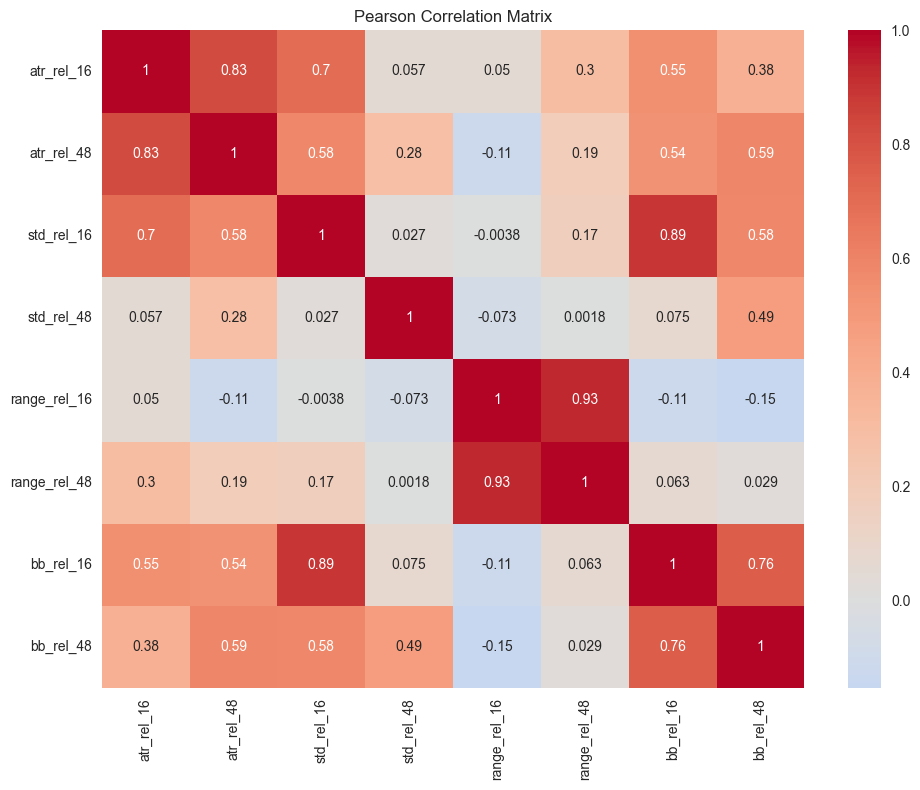

In [6]:
plt.figure(figsize=(10,8))
sns.heatmap(pearson_corr, annot=True, cmap="coolwarm", center=0)
plt.title("Pearson Correlation Matrix")
plt.tight_layout()

plt.savefig("C:/Users/LENOVO/AlgoTrading_Research/statistical-range-detection/figures/pearson_correlation_matrix.png")
plt.show()

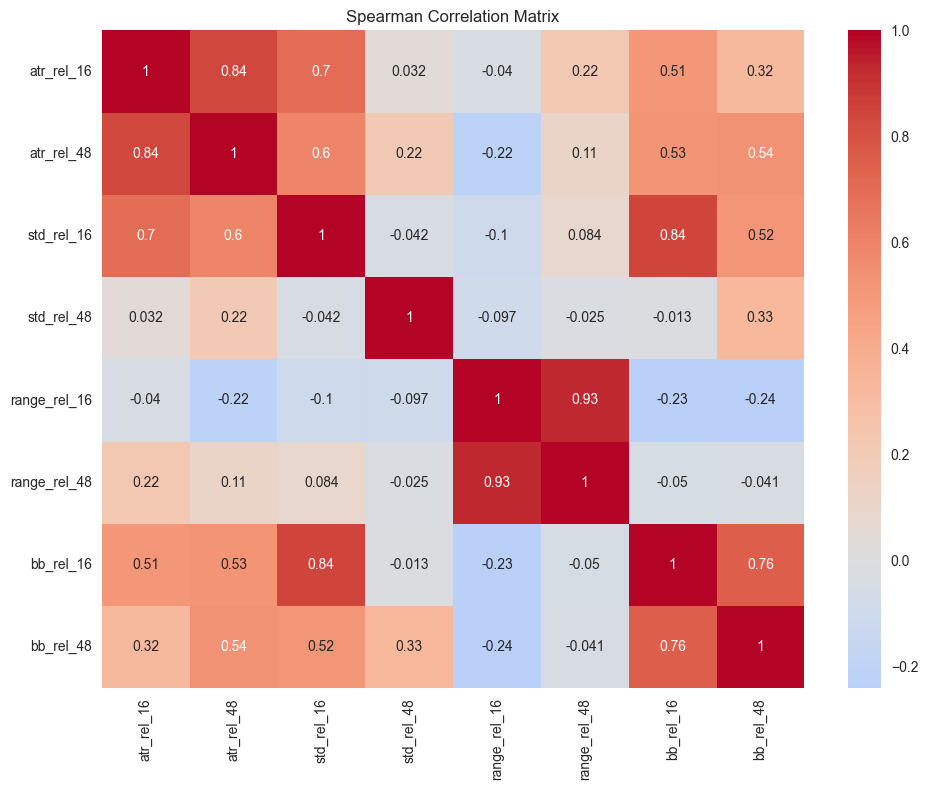

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(spearman_corr, annot=True, cmap="coolwarm", center=0)
plt.title("Spearman Correlation Matrix")
plt.tight_layout()

plt.savefig("C:/Users/LENOVO/AlgoTrading_Research/statistical-range-detection/figures/spearman_correlation_matrix.png")
plt.show()

## Feature Distribution Analysis

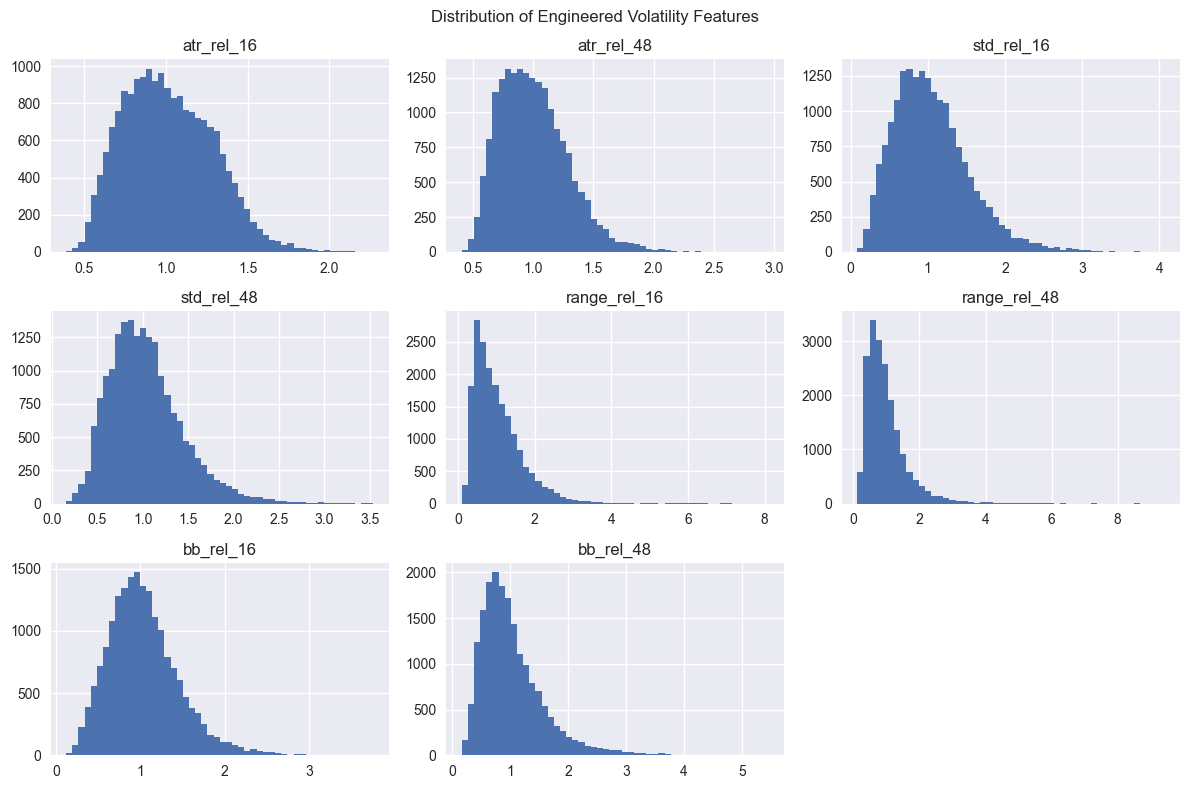

In [8]:
feature_df.hist(bins=50, figsize=(12,8))
plt.suptitle("Distribution of Engineered Volatility Features")
plt.tight_layout()

plt.savefig("C:/Users/LENOVO/AlgoTrading_Research/statistical-range-detection/figures/feature_distributions.png")
plt.show()

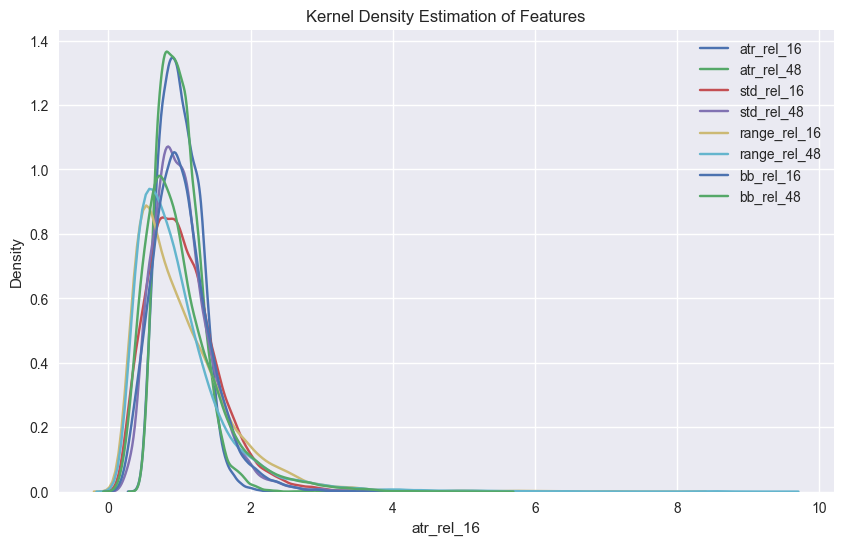

In [9]:
plt.figure(figsize=(10,6))
for col in features:
    sns.kdeplot(feature_df[col], label=col)
plt.legend()
plt.title("Kernel Density Estimation of Features")

plt.savefig("C:/Users/LENOVO/AlgoTrading_Research/statistical-range-detection/figures/feature_KDEDistribution.png")
plt.show()

## Feature Grouping via Hierarchical Clustering

In [10]:
corr = feature_df.corr()
distance_matrix = 1 - np.abs(corr)

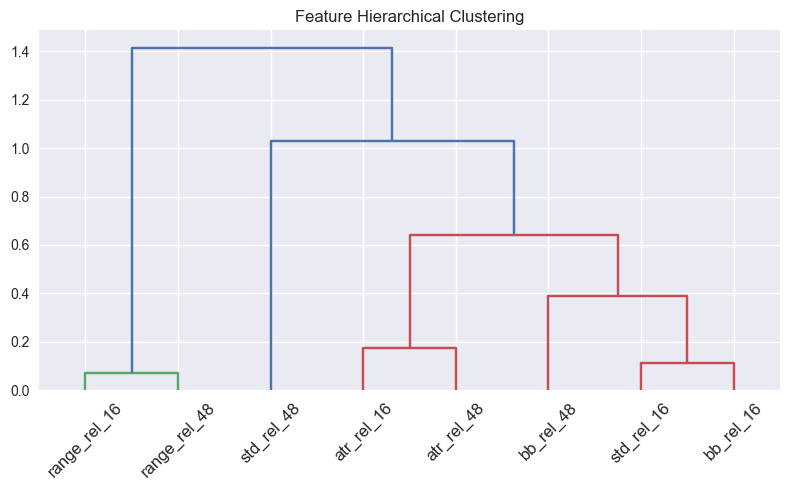

In [11]:
condensed_dist = squareform(distance_matrix)
Z = linkage(condensed_dist, method="ward")

plt.figure(figsize=(8,5))
dendrogram(Z, labels=features, leaf_rotation=45)

plt.title("Feature Hierarchical Clustering")
plt.tight_layout()

plt.savefig("C:/Users/LENOVO/AlgoTrading_Research/statistical-range-detection/figures/feature_clustering_dendrogram.png")
plt.show()

## Feature Correlation Network

In [12]:
corr = feature_df.corr()
threshold = 0.5
G = nx.Graph()

for col in corr.columns:
    G.add_node(col)
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i,j]) > threshold:
            G.add_edge(corr.columns[i], corr.columns[j], weight=corr.iloc[i,j])

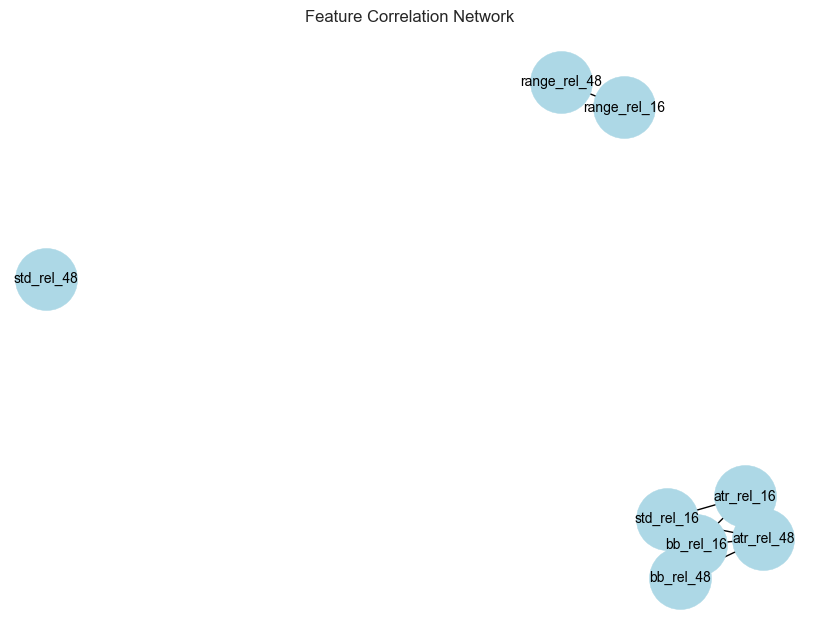

In [13]:
plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_size=2000, node_color="lightblue", font_size=10)
plt.title("Feature Correlation Network")

plt.savefig("C:/Users/LENOVO/AlgoTrading_Research/statistical-range-detection/figures/feature_correlation_network.png")
plt.show()

# Feature Group Analysis for Range Detection

In [14]:
short_vol = ["atr_rel_16","std_rel_16","bb_rel_16"]
mid_vol = ["atr_rel_48","std_rel_48","bb_rel_48"]
candle_range = ["range_rel_16","range_rel_48"]

In [15]:
stability = df[short_vol + mid_vol + candle_range].std()
stability.sort_values()

atr_rel_16      0.273089
atr_rel_48      0.286473
std_rel_48      0.418663
bb_rel_16       0.423578
std_rel_16      0.496224
bb_rel_48       0.554549
range_rel_48    0.688181
range_rel_16    0.691931
dtype: float64

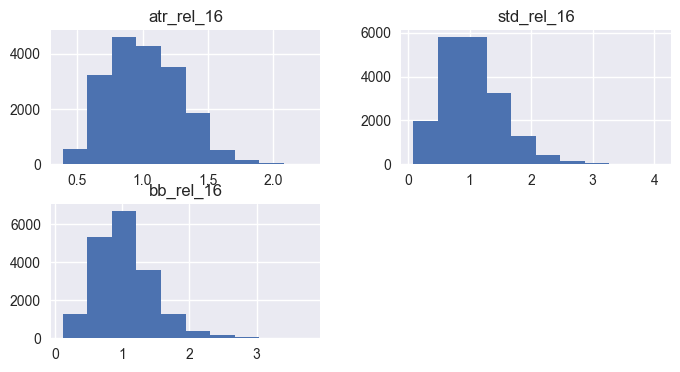

In [16]:
df[short_vol].hist(figsize=(8,4))
plt.show()

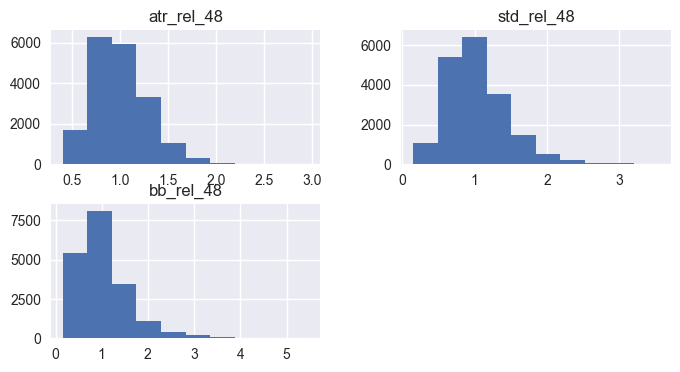

In [17]:
df[mid_vol].hist(figsize=(8,4))
plt.show()

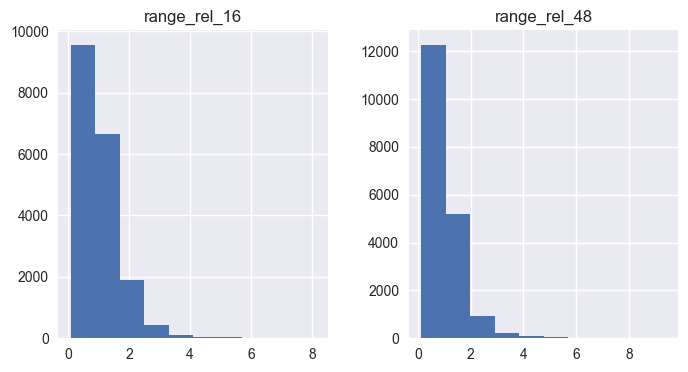

In [18]:
df[candle_range].hist(figsize=(8,4))
plt.show()

In [19]:
df[short_vol].corr()

,atr_rel_16,std_rel_16,bb_rel_16
atr_rel_16,1.000000,0.699764,0.552593
std_rel_16,0.699764,1.000000,0.888487
bb_rel_16,0.552593,0.888487,1.000000


In [20]:
df[mid_vol].corr()

,atr_rel_48,std_rel_48,bb_rel_48
atr_rel_48,1.000000,0.283636,0.585747
std_rel_48,0.283636,1.000000,0.485449
bb_rel_48,0.585747,0.485449,1.000000


In [21]:
df[candle_range].corr()

,range_rel_16,range_rel_48
range_rel_16,1.000000,0.929326
range_rel_48,0.929326,1.000000


In [22]:
corr = df[short_vol + mid_vol + candle_range].corr().abs()
corr.mean().sort_values()

std_rel_48      0.250245
range_rel_16    0.304994
range_rel_48    0.334930
atr_rel_16      0.482664
std_rel_16      0.493203
bb_rel_48       0.496379
bb_rel_16       0.499439
atr_rel_48      0.514038
dtype: float64